In [61]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import joblib
import pickle
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
#for dirname, _, filenames in os.walk('/kaggle/input'):
#    for filename in filenames:
#        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
df = pd.read_csv('data.csv')

## 1. Check Data ##

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [16]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

In [17]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


## 2. EDA ##

## Fraud vs Non-Fraud Population ##

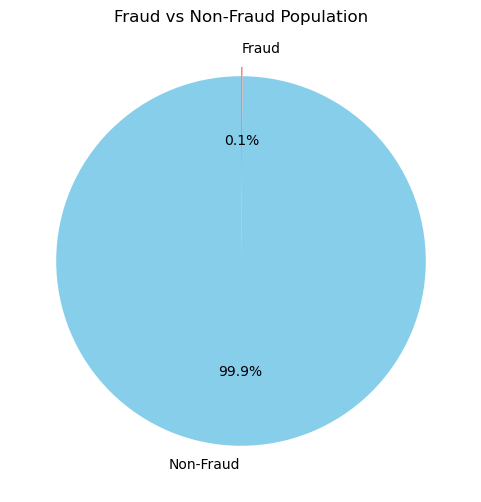

In [19]:
import matplotlib.pyplot as plt

# Basic counts
fraud_counts = df['isFraud'].value_counts()

# Labels for the pie chart
labels = ['Non-Fraud', 'Fraud']

# Pie chart
plt.figure(figsize=(6,6))
plt.pie(
    fraud_counts,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue', 'salmon'],
    explode=[0, 0.05]  # slightly pull out the fraud slice
)
plt.title('Fraud vs Non-Fraud Population')
plt.show()


## Distribution of Transaction Types ##

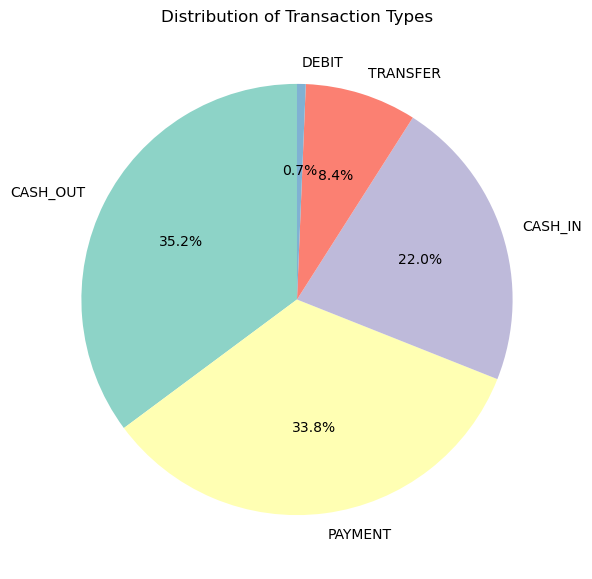

In [20]:
# Count each transaction type
type_counts = df['type'].value_counts()

# Pie chart
plt.figure(figsize=(7,7))
plt.pie(
    type_counts,
    labels=type_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3.colors  # nice categorical palette
)
plt.title('Distribution of Transaction Types')
plt.show()

## Fraud Rate by Transaction Type ##

Fraud Rate by Transaction Type (%):

type
CASH_IN     0.000000
CASH_OUT    0.183955
DEBIT       0.000000
PAYMENT     0.000000
TRANSFER    0.768799
Name: isFraud, dtype: float64


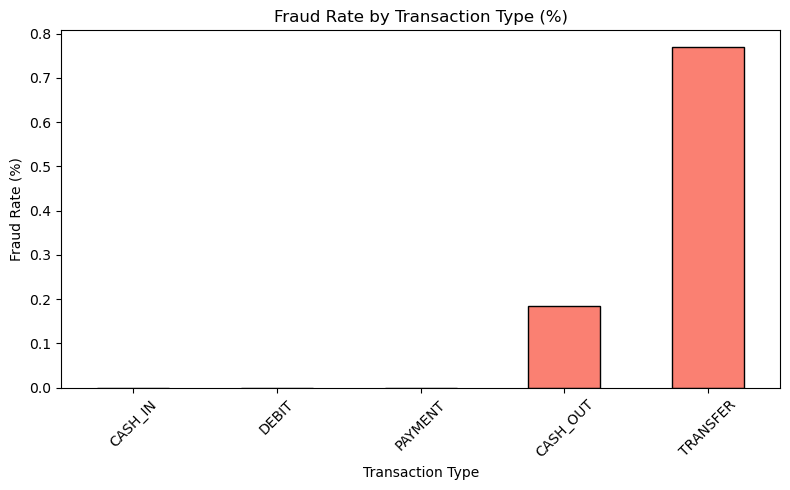

In [21]:
# Calculate fraud rate per transaction type
fraud_rate = df.groupby('type')['isFraud'].mean() * 100
print("Fraud Rate by Transaction Type (%):\n")
print(fraud_rate)

# Plot fraud rate
plt.figure(figsize=(8,5))
fraud_rate.sort_values().plot(
    kind='bar',
    color='salmon',
    edgecolor='black'
)

plt.title('Fraud Rate by Transaction Type (%)')
plt.ylabel('Fraud Rate (%)')
plt.xlabel('Transaction Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Fraud Transactions Over Time (per Step) ##

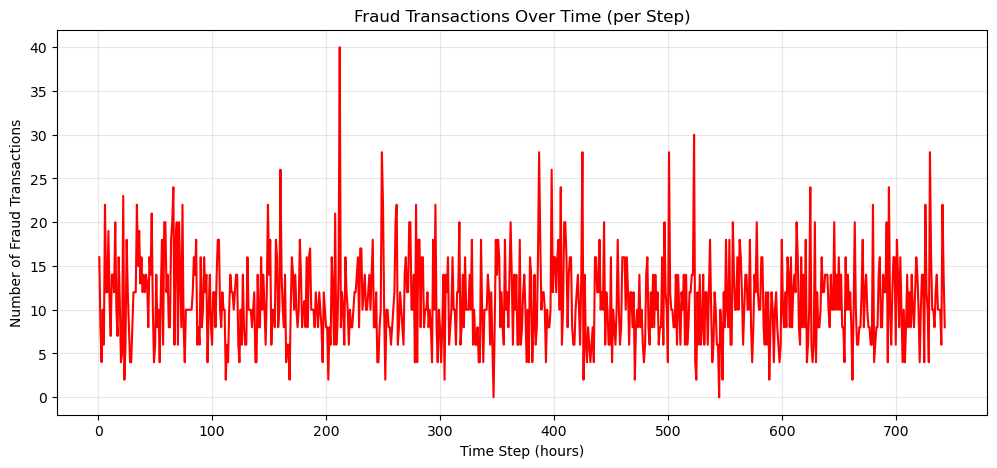

In [22]:
# Fraud count per time step
fraud_per_step = df.groupby('step')['isFraud'].sum()

plt.figure(figsize=(12,5))
plt.plot(fraud_per_step, color='red', linewidth=1.5)
plt.title('Fraud Transactions Over Time (per Step)')
plt.xlabel('Time Step (hours)')
plt.ylabel('Number of Fraud Transactions')
plt.grid(alpha=0.3)
plt.show()

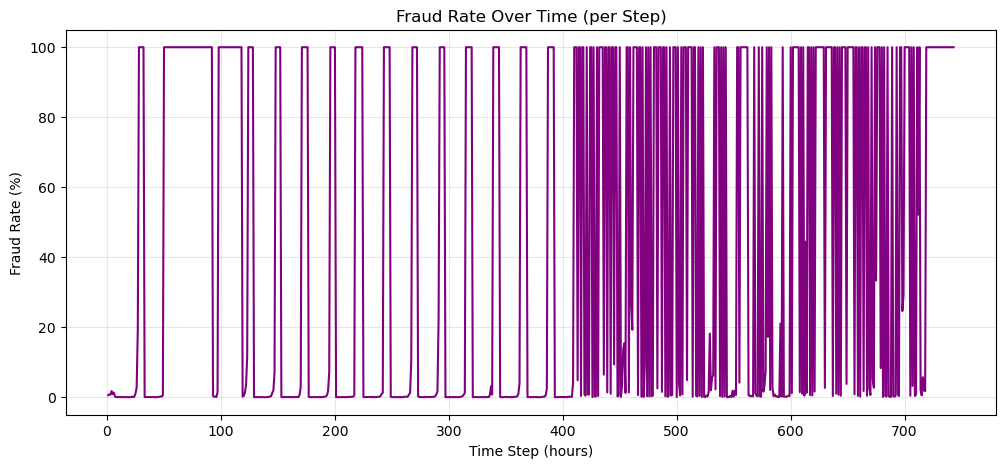

In [23]:
# Fraud rate = fraud / total transactions per step
fraud_rate_step = df.groupby('step')['isFraud'].mean() * 100

plt.figure(figsize=(12,5))
plt.plot(fraud_rate_step, color='purple', linewidth=1.5)
plt.title('Fraud Rate Over Time (per Step)')
plt.xlabel('Time Step (hours)')
plt.ylabel('Fraud Rate (%)')
plt.grid(alpha=0.3)
plt.show()

## Total vs Fraud Transactions Over Time ##

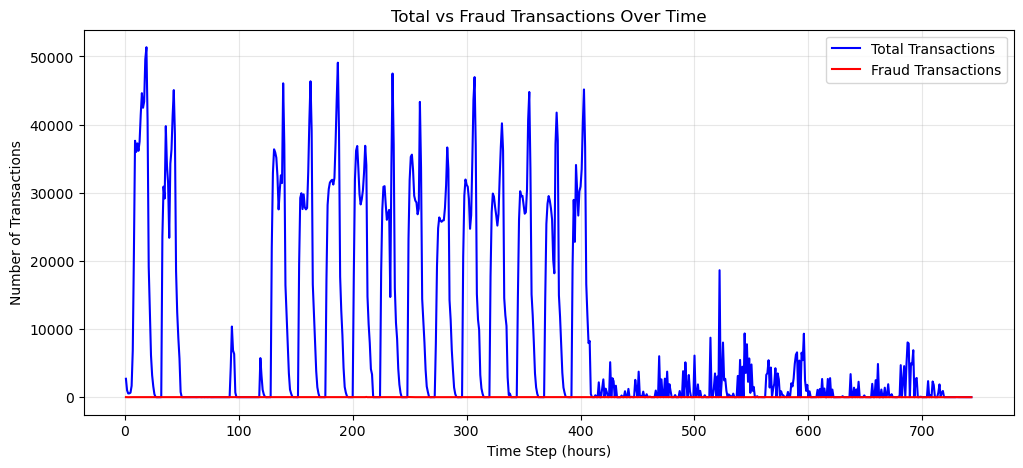

In [24]:
# Transactions per step
tx_per_step = df.groupby('step').size()
fraud_per_step = df.groupby('step')['isFraud'].sum()

plt.figure(figsize=(12,5))
plt.plot(tx_per_step, label='Total Transactions', color='blue')
plt.plot(fraud_per_step, label='Fraud Transactions', color='red')
plt.title('Total vs Fraud Transactions Over Time')
plt.xlabel('Time Step (hours)')
plt.ylabel('Number of Transactions')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Receiver Account Profiling ##

In [25]:
# Count how many transactions each receiver gets
top_receivers = df['nameDest'].value_counts().head(10)
print(top_receivers)

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64


In [26]:
# Top 10 receivers involved in fraudulent transactions
fraud_receivers = df[df['isFraud'] == 1]['nameDest'].value_counts().head(10)
print(fraud_receivers)

nameDest
C1193568854    2
C104038589     2
C200064275     2
C1497532505    2
C1601170327    2
C1655359478    2
C2020337583    2
C1653587362    2
C1013511446    2
C2129197098    2
Name: count, dtype: int64


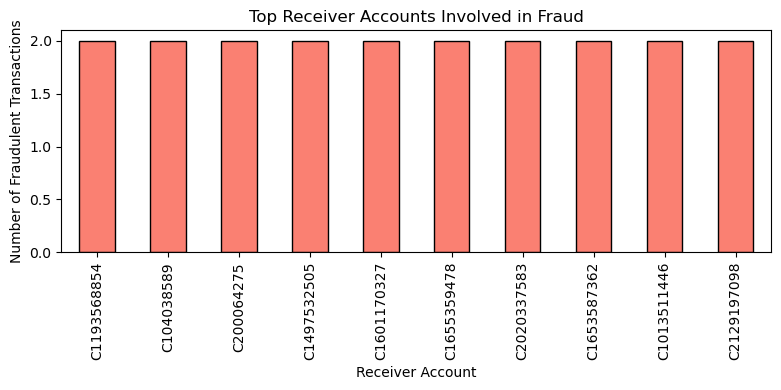

In [27]:
fraud_receivers.head(10).plot(
    kind='bar',
    figsize=(8,4),
    color='salmon',
    edgecolor='black'
)
plt.title('Top Receiver Accounts Involved in Fraud')
plt.xlabel('Receiver Account')
plt.ylabel('Number of Fraudulent Transactions')
plt.tight_layout()
plt.show()


## Account with 100% Fraud Rate ##

In [28]:
# Fraud rate per receiver account
fraud_rate_receivers = (
    df.groupby('nameDest')['isFraud'].mean() * 100
).sort_values(ascending=False)

print(fraud_rate_receivers.head(10))

nameDest
C93455814      100.0
C1963548176    100.0
C411004597     100.0
C584314061     100.0
C2103213802    100.0
C1650736473    100.0
C1815024407    100.0
C1802674568    100.0
C746130258     100.0
C364328277     100.0
Name: isFraud, dtype: float64


## Detect Impossible Balance Movements ##

In [29]:
# Checks for impossible balance behaviour
impossible_sender = df[df['oldbalanceOrg'] - df['amount'] != df['newbalanceOrig']]
impossible_receiver = df[df['oldbalanceDest'] + df['amount'] != df['newbalanceDest']]

print("Impossible Sender Balance Changes:", len(impossible_sender))
print("Impossible Receiver Balance Changes:", len(impossible_receiver))

Impossible Sender Balance Changes: 5413997
Impossible Receiver Balance Changes: 4736674


## Transactions Where Money ‘Appears’ or ‘Disappears’ ##

In [30]:
money_appears = df[
    (df['oldbalanceDest'] == 0) &
    (df['amount'] > 0) &
    (df['newbalanceDest'] == df['amount'])
]

money_appears.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
811,1,TRANSFER,84212.94,C1336775847,53199.00,0.00,C13329486,0.0,84212.94,0,0
1169,1,CASH_OUT,9980.32,C1589466857,12936.00,2955.68,C1018298342,0.0,9980.32,0,0
1428,1,TRANSFER,139555.44,C1733619456,19466.00,0.00,C317071334,0.0,139555.44,0,0
1911,1,CASH_OUT,132842.64,C13692003,4499.08,0.00,C297927961,0.0,132842.64,1,0
2125,1,TRANSFER,22190.99,C2017380745,52231.01,30040.03,C1170794006,0.0,22190.99,0,0


In [31]:
money_disappears = df[
    (df['amount'] > 0) &
    (df['oldbalanceOrg'] == df['newbalanceOrig'])
]

money_disappears.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
29,1,PAYMENT,9920.52,C764826684,0.0,0.0,M1940055334,0.0,0.0,0,0
30,1,PAYMENT,3448.92,C2103763750,0.0,0.0,M335107734,0.0,0.0,0,0
31,1,PAYMENT,4206.84,C215078753,0.0,0.0,M1757317128,0.0,0.0,0,0
32,1,PAYMENT,5885.56,C840514538,0.0,0.0,M1804441305,0.0,0.0,0,0
33,1,PAYMENT,5307.88,C1768242710,0.0,0.0,M1971783162,0.0,0.0,0,0


## Boolean Flag for Balance Anomalies ##

In [32]:
df['balance_anomaly'] = (
    (df['oldbalanceOrg'] - df['amount'] != df['newbalanceOrig']) |
    (df['oldbalanceDest'] + df['amount'] != df['newbalanceDest'])
)

df['balance_anomaly'].value_counts()

balance_anomaly
True     6240563
False     122057
Name: count, dtype: int64

## Fraud Rate Among Anomalous Transactions ##

In [33]:
fraud_rate_anomaly = df.groupby('balance_anomaly')['isFraud'].mean() * 100
print(fraud_rate_anomaly)

balance_anomaly
False    2.354638
True     0.085553
Name: isFraud, dtype: float64


## Anomalous Fraud Cases ##

In [34]:
anomalous_fraud = df[(df['balance_anomaly'] == True) & (df['isFraud'] == 1)]
anomalous_fraud.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_anomaly
2,1,TRANSFER,181.0,C1305486145,181.0,0.0,C553264065,0.0,0.0,1,0,True
3,1,CASH_OUT,181.0,C840083671,181.0,0.0,C38997010,21182.0,0.0,1,0,True
251,1,TRANSFER,2806.0,C1420196421,2806.0,0.0,C972765878,0.0,0.0,1,0,True
252,1,CASH_OUT,2806.0,C2101527076,2806.0,0.0,C1007251739,26202.0,0.0,1,0,True
680,1,TRANSFER,20128.0,C137533655,20128.0,0.0,C1848415041,0.0,0.0,1,0,True


## Correlation Matrix (with Heatmap) ##

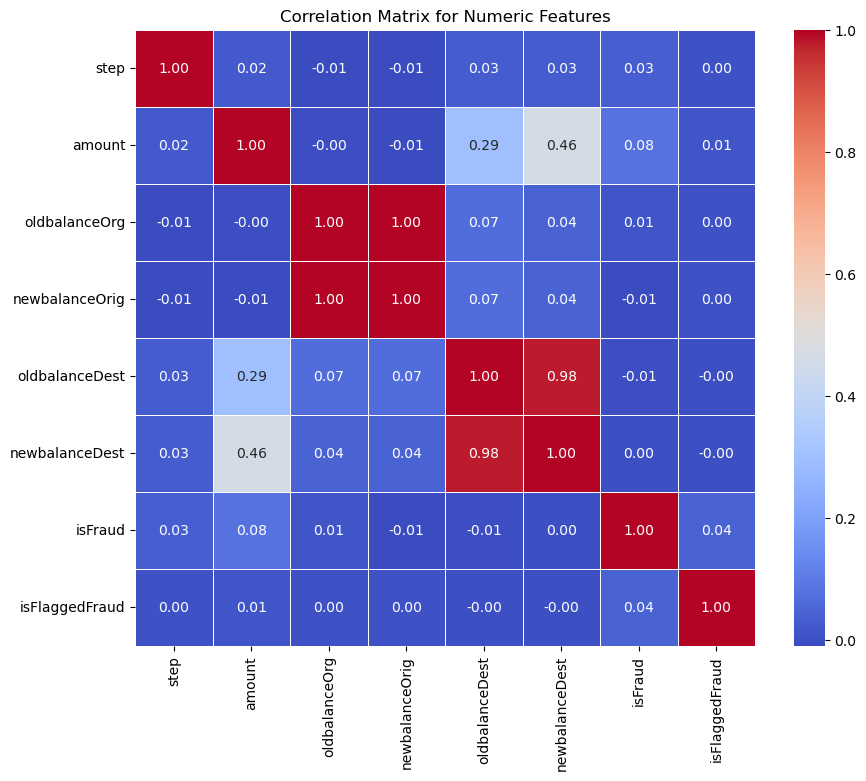

In [35]:
import seaborn as sns

# Select numeric columns only
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# Compute correlation matrix
corr_matrix = numeric_df.corr()

# Plot
plt.figure(figsize=(10,8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    linewidths=0.5,
    fmt=".2f"
)
plt.title('Correlation Matrix for Numeric Features')
plt.show()

## Highlights from Correlation Matrix ##

1. Balances on the sender side are perfectly correlated. This suggests that, for most transactions, the sender’s balance follows a predictable linear relationship with the amount.
2. Balances on the receiver side are also highly correlated. Receiver balances change in a consistent way for most transactions.
3. Amount is mildly correlated with destination balances. No strong fraud link here.
4. There is almost zero correlation between isFraud and any numeric variable. Fraud cannot be detected with simple linear correlations. Fraudsters mimic normal behaviour to evade detection.
5. isFlaggedFraud correlation is near zero. It shows that rule‑based detection fails, and ML models or forensic pattern analysis are needed.

## 3. ML Model ##

In [36]:

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression


In [37]:
# Select columns for baseline model
df_model = df[['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
               'oldbalanceDest', 'newbalanceDest', 'isFraud']]

In [38]:
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=True)

In [39]:
X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Logistic Regression ##

In [40]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
model = LogisticRegression(max_iter=500)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=500)

In [42]:
y_pred = model.predict(X_test_scaled)

In [43]:
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.90      0.38      0.53      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.69      0.77   1272524
weighted avg       1.00      1.00      1.00   1272524


Confusion Matrix:
[[1270813      68]
 [   1019     624]]


Model performs extremely well on non‑fraud. However, it is not our aim.

Fraud recall = 38%, which is high. Therefore Logistic Regression is not effective in predicting fraud.

## Random Forest model ##

In [44]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [45]:
rf = RandomForestClassifier(
    n_estimators=80,
    max_depth=12,
    max_features='log2',
    min_samples_leaf=20,
    class_weight='balanced',
    n_jobs=-1,
    random_state=42
)


In [46]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=12,
                       max_features='log2', min_samples_leaf=20,
                       n_estimators=80, n_jobs=-1, random_state=42)

In [47]:
y_pred = rf.predict(X_test)

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00   1270881
           1       0.13      0.99      0.22      1643

    accuracy                           0.99   1272524
   macro avg       0.56      0.99      0.61   1272524
weighted avg       1.00      0.99      0.99   1272524


Confusion Matrix:
[[1259569   11312]
 [     15    1628]]


Precision: 0.13: Only 13% of flagged transactions are truly fraud

Recall: 0.99: The model catches 99% of all fraud

F1: 0.22: Low due to imbalance between precision & recall

This model only misses 15 Fraud cases.

However, it is also flagging 11,312 legitimate transactions as fraud.

## XGBoost ##

In [48]:
!pip install xgboost

In [49]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

In [50]:
# Features
df_model = df[['type', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
               'oldbalanceDest', 'newbalanceDest', 'isFraud']]

# One-hot encoding
df_model = pd.get_dummies(df_model, columns=['type'], drop_first=True)

X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']

In [51]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [52]:
ratio = len(y_train[y_train == 0]) / len(y_train[y_train == 1])
print("Scale_pos_weight:", ratio)

Scale_pos_weight: 773.7482496194825


In [53]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=ratio,
    eval_metric='logloss',
    tree_method='hist',   # FASTEST (uses histogram optimization)
    random_state=42
)


In [54]:
xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [55]:
y_pred = xgb.predict(X_test)

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.40      0.99      0.57      1643

    accuracy                           1.00   1272524
   macro avg       0.70      1.00      0.78   1272524
weighted avg       1.00      1.00      1.00   1272524


Confusion Matrix:
[[1268432    2449]
 [     13    1630]]


It only misses 13 fraud cases out of 1,643.

It keeps false positives relatively low (2,444 out of 1.27M)

Accuracy remains ~100%

It is better model

Tuning the XGBosst for higer precision

In [56]:
y_prob = xgb.predict_proba(X_test)[:, 1]

# Try a stricter threshold
threshold = 0.7
y_pred_adj = (y_prob > threshold).astype(int)

print(classification_report(y_test, y_pred_adj))
print(confusion_matrix(y_test, y_pred_adj))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.48      0.99      0.64      1643

    accuracy                           1.00   1272524
   macro avg       0.74      0.99      0.82   1272524
weighted avg       1.00      1.00      1.00   1272524

[[1269092    1789]
 [     18    1625]]


In [57]:
df['fraud_risk'] = xgb.predict_proba(X)[:, 1]

In [58]:
df.sort_values('fraud_risk', ascending=False).head(20)

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_anomaly,fraud_risk
1653384,158,TRANSFER,3457169.26,C1868574170,3457169.26,0.0,C1851909652,0.0,0.0,1,0,True,0.999998
1030343,58,TRANSFER,3156421.43,C1609180237,3156421.43,0.0,C1443408255,0.0,0.0,1,0,True,0.999998
6360680,716,TRANSFER,1897921.70,C860413679,1897921.70,0.0,C1253519573,0.0,0.0,1,0,True,0.999998
576334,28,TRANSFER,3832058.34,C1279307827,3832058.34,0.0,C1124913173,0.0,0.0,1,0,True,0.999998
6006725,430,TRANSFER,2828068.73,C1916200037,2828068.73,0.0,C483349301,0.0,0.0,1,0,True,0.999998
4244886,306,TRANSFER,2052851.64,C1016160383,2052851.64,0.0,C1670523748,0.0,0.0,1,0,True,0.999998
6038568,479,TRANSFER,6669495.34,C1780532253,6669495.34,0.0,C2065569880,0.0,0.0,1,0,True,0.999998
6037805,478,TRANSFER,2254718.25,C1119251343,2254718.25,0.0,C1394440708,0.0,0.0,1,0,True,0.999998
6007596,431,TRANSFER,3718503.37,C336342996,3718503.37,0.0,C190775867,0.0,0.0,1,0,True,0.999998
1030341,58,TRANSFER,6501303.14,C2083819202,6501303.14,0.0,C1581398768,0.0,0.0,1,0,True,0.999998


These are transactions needed to be investigated. We can amend if requires to 50 or even more.

In [59]:
def risk_bucket(score):
    if score > 0.9:
        return "Very High Risk"
    elif score > 0.7:
        return "High Risk"
    elif score > 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

df['risk_bucket'] = df['fraud_risk'].apply(risk_bucket)


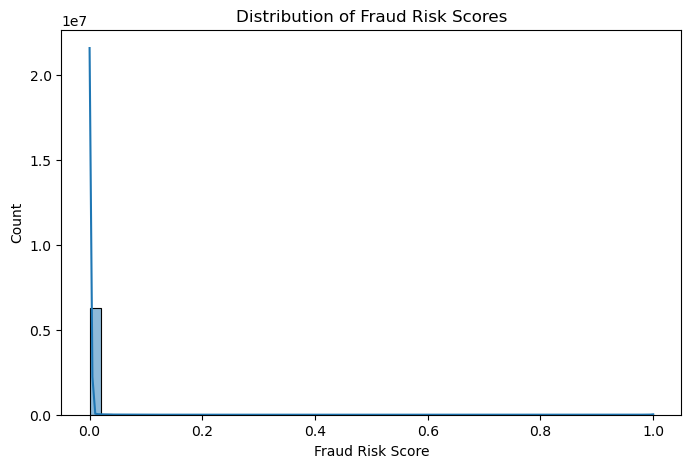

In [60]:
plt.figure(figsize=(8,5))
sns.histplot(df['fraud_risk'], bins=50, kde=True)
plt.title("Distribution of Fraud Risk Scores")
plt.xlabel("Fraud Risk Score")
plt.ylabel("Count")
plt.show()


In [62]:
# Save XGBoost model
joblib.dump(xgb, 'xgboost_fraud_model.pkl')

# Save full DataFrame (with fraud_risk & risk_bucket columns)
with open('fraud_data.pkl', 'wb') as f:
    pickle.dump(df, f)

# Load-back verification
model_loaded = joblib.load('xgboost_fraud_model.pkl')
with open('fraud_data.pkl', 'rb') as f:
    df_loaded = pickle.load(f)
